# EXTRA — reproducing the abstract

This notebook recomputes the three results reported in the SSAC 2027 abstract from the outputs of the pipeline in the README:

1. **Table 1** — 2025 held-out R² for the npxG difference (linear baseline, EventXI, EXTRA) and the paired match bootstrap.
2. **Within-position rank correlations** — high-intensity share in the pressing phase vs the attacking phases.
3. **Figure 1** — the case study (coach's eleven, EventXI and EXTRA recommendations).

The licensed data are not distributed, so the cells only run after the pipeline has produced `outputs/` and `vaep/output/`. The saved outputs below come from the authors' run and show aggregate numbers and the figure only.

In [1]:
from pathlib import Path
import os, sys, subprocess
import numpy as np, pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUT = ROOT / "outputs"
VAEP = ROOT / "vaep" / "output"
pd.set_option("display.precision", 4)

## 1. Table 1 — 2025 held-out R²

Both models are trained on 2024 with player histories from 2024 on (`TRAINFROM=2024 HISTFROM=2024`), five seeds averaged, stage 2. The linear baseline is a ridge regression on the two elevens' event features. The bootstrap resamples games (both team rows together) 2,000 times.

In [2]:
def r2(y, p):
    return 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()

tag = "ssn2025-set1-cross0-H16-L1-none-full-stage2-days-warm-fam5-ssac24h{}-s5"
A = np.load(OUT / f"player_encoder_set_{tag.format('A')}.npz")   # EventXI (event data)
T = np.load(OUT / f"player_encoder_set_{tag.format('T')}.npz")   # EXTRA (event + phase-tracking data)
season = pd.read_csv(VAEP / "games.csv", usecols=["game_id", "season"]).set_index("game_id").season
gid, y = A["game_id"], A["y"]
m = (season.reindex(gid).to_numpy() == 2025) & np.isfinite(A["set"]) & np.isfinite(T["set"])
yy, gg = y[m], gid[m]
pred = {"Linear baseline": A["linear"][m], "EventXI (event data)": A["set"][m], "EXTRA (event + phase-tracking data)": T["set"][m]}

table1 = pd.DataFrame({"R2": {k: r2(yy, p) for k, p in pred.items()}})
table1.index.name = f"2025 held out ({m.sum()} team-matches)"
table1

,R2
2025 held out (982 team-matches),
Linear baseline,0.1435
EventXI (event data),0.1620
EXTRA (event + phase-tracking data),0.1771


In [3]:
games = np.unique(gg); idx = {k: np.flatnonzero(gg == k) for k in games}
rng = np.random.default_rng(0)
B = [np.concatenate([idx[k] for k in rng.choice(games, len(games))]) for _ in range(2000)]
pe, pt = pred["EventXI (event data)"], pred["EXTRA (event + phase-tracking data)"]
d = np.array([r2(yy[b], pt[b]) - r2(yy[b], pe[b]) for b in B])
print(f"EXTRA - EventXI: dR2 = {r2(yy, pt) - r2(yy, pe):+.4f}, "
      f"95% CI [{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}], "
      f"positive in {100 * (d > 0).mean():.0f}% of {len(B):,} resamples")

EXTRA - EventXI: dR2 = +0.0151, 95% CI [-0.0064, +0.0376], positive in 90% of 2,000 resamples


## 2. Within-position rank correlations

Outfield players with at least ten tracked matches; each player's mean high-intensity share (> 5.5 m/s) per phase; the mean of the player's modal position is subtracted before the Spearman correlation.

In [4]:
g = pd.read_csv(VAEP / "games.csv", usecols=["game_id", "game_date"])
pp = pd.read_parquet(OUT / "player_phase_match.parquet")
pp = pp[(pp.tax == "phase") & (pp.pos != "GK") & pp.ex_pid.notna()].merge(g, on="game_id")
pp = pp[pp.minutes >= 1.0]
cnt = pp.groupby("ex_pid").game_id.nunique(); q = pp[pp.ex_pid.isin(cnt[cnt >= 10].index)]
H = q.groupby(["ex_pid", "label"]).hi.mean().unstack("label")
pos = q.groupby("ex_pid").pos.agg(lambda s: s.mode().iloc[0])
W = H.sub(H.groupby(pos).transform("mean"))
pairs = [("pressing", "settled_attack"), ("pressing", "transition_attack")]
pd.DataFrame({"all outfield players": [H[a].corr(H[b], method="spearman") for a, b in pairs],
              "within position": [W[a].corr(W[b], method="spearman") for a, b in pairs]},
             index=[f"{a} vs {b}" for a, b in pairs]).rename_axis(f"{len(H)} players")

,all outfield players,within position
741 players,,
pressing vs settled_attack,-0.2016,0.1580
pressing vs transition_attack,-0.2055,0.1683


## 3. Figure 1 — case study

Jeonbuk Hyundai Motors vs Gwangju FC, 23 February 2025. The lineup solver runs in `case_study/` (`score_lineup.py --h24`, `scan_coach_cases.py`); this cell redraws the figure from the scan. Substitution minutes and the realised npxG difference are drawn after the case is fixed.

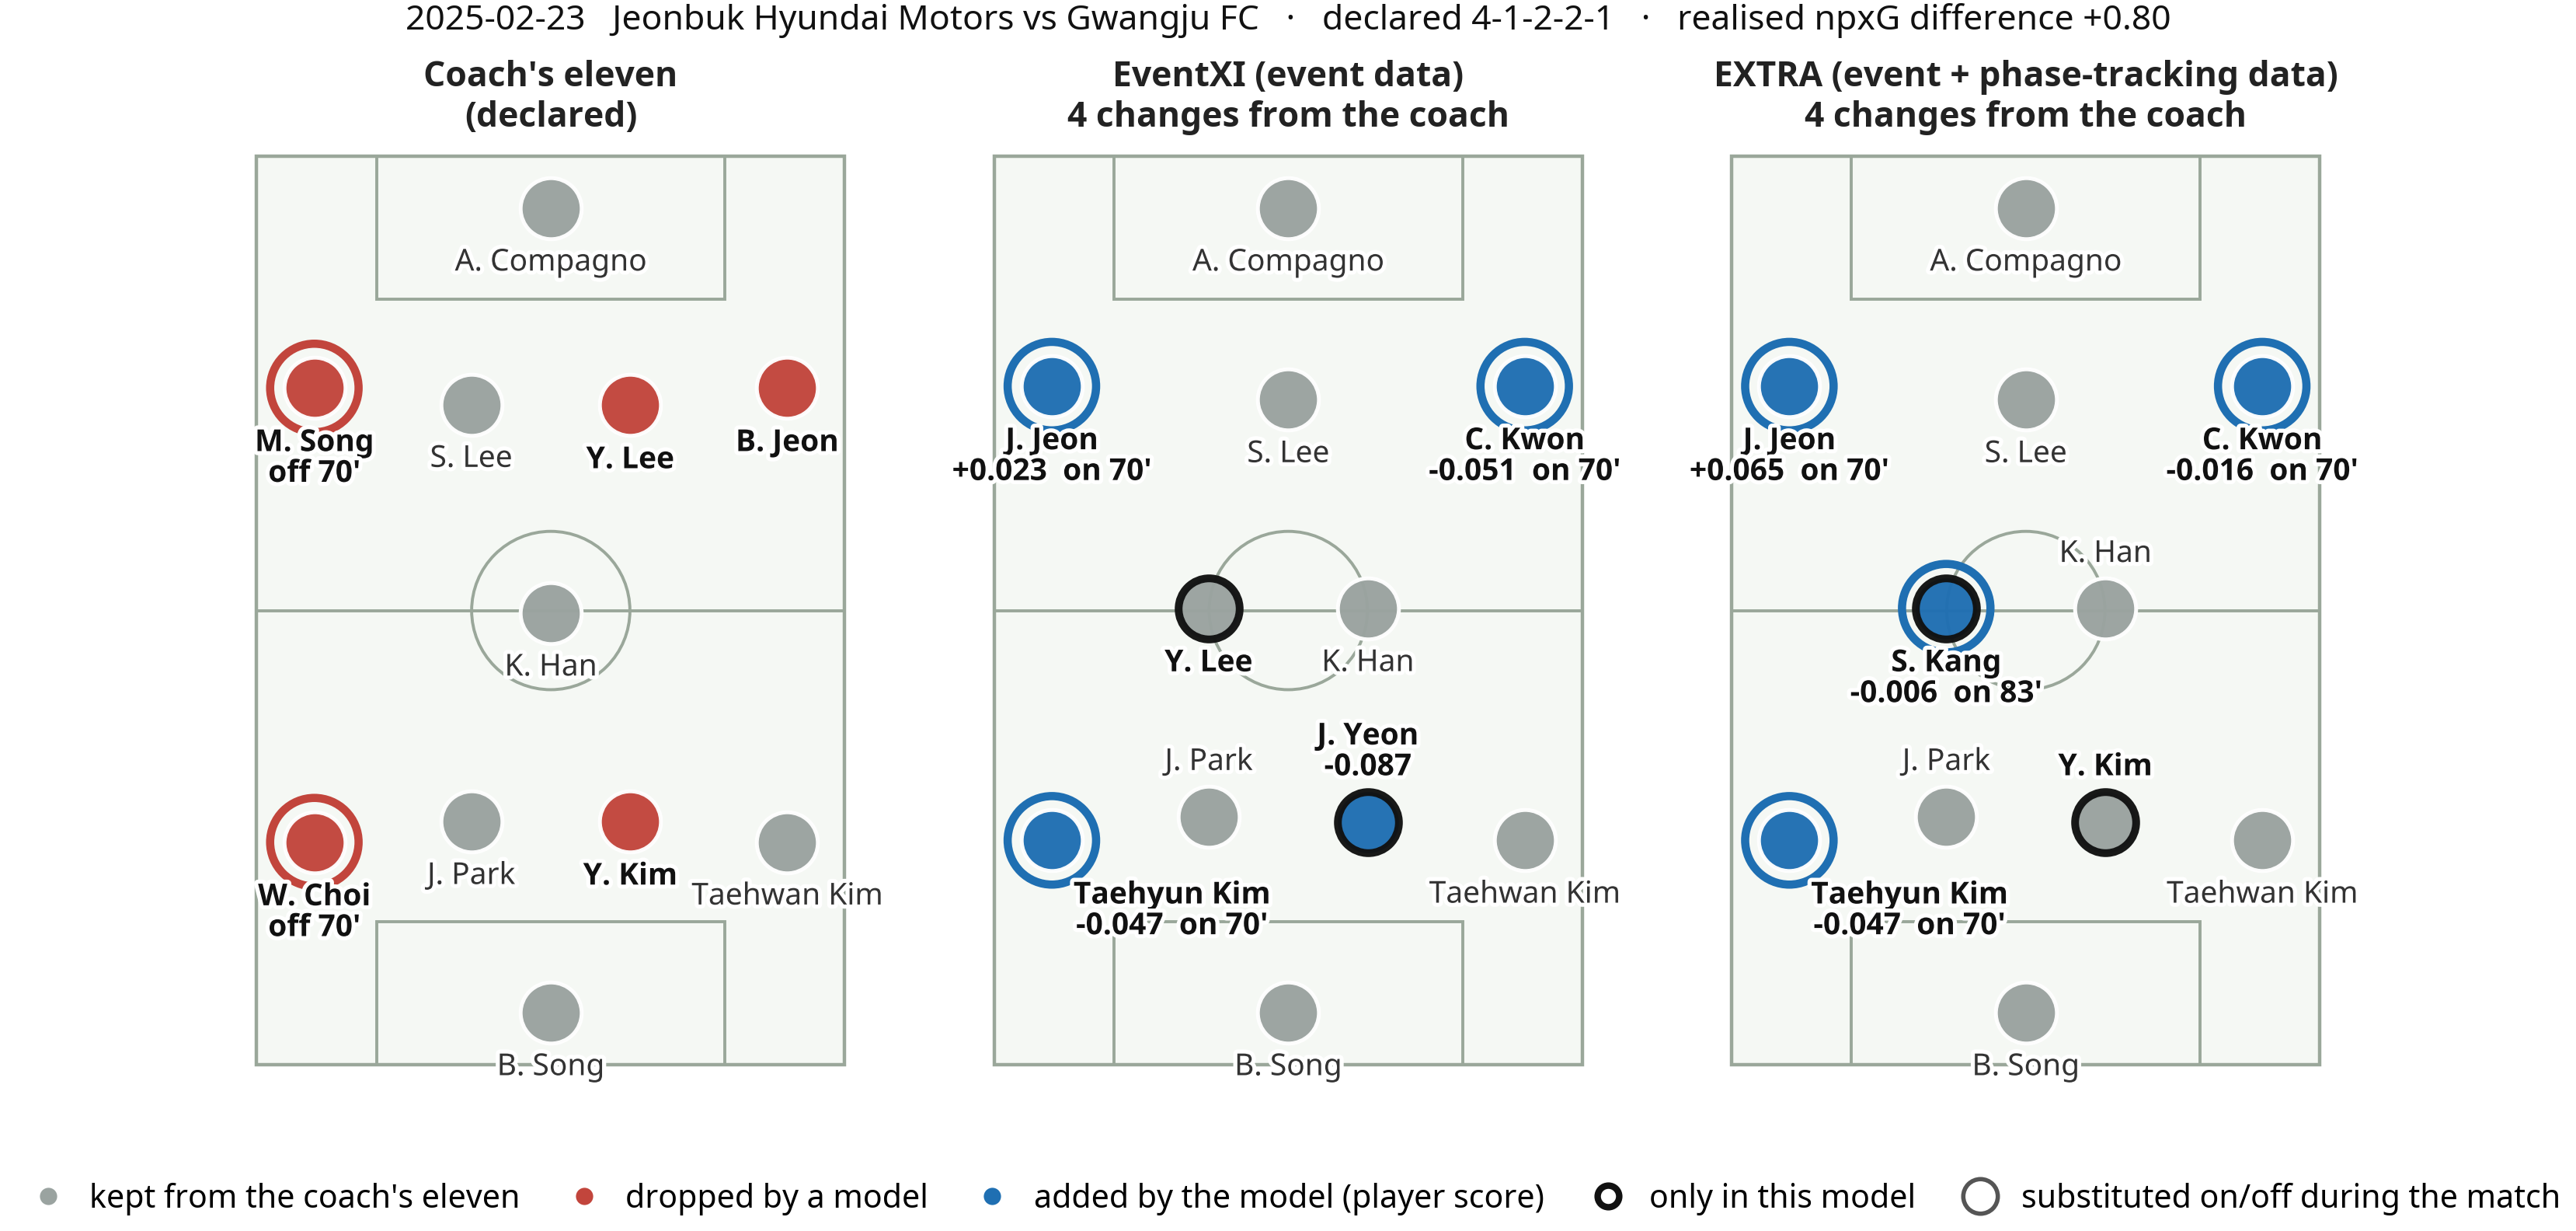

In [5]:
from IPython.display import Image
fig = ROOT / "figures" / "case_study"
r = subprocess.run([sys.executable, "-W", "ignore", "case_study/coach_case_figure.py", "--pin", "165309:4640", "--out", str(fig)],
                   cwd=ROOT, env={**os.environ, "SUF": "_h24"}, capture_output=True, text=True)
assert r.returncode == 0, r.stderr[-2000:]
Image(filename=str(fig) + ".png", width=900)